# Premier League Betting Market Efficiency Study

This notebook tests how difficult it is to beat Premier League bookmaker opening odds. It loads historical match data, builds pre-match team features, trains several simple model variants, and evaluates them against a true out-of-sample 2025-2026 test set from `E0 (1).csv`.

The project is now framed as a market-efficiency analysis rather than a promise of profitable predictions. The key questions are:

- Are Bet365 opening odds well calibrated?
- Do team-form, Elo, xG, rest, and congestion features improve on the opening market?
- Do model-selected bets make money after realistic assumptions?
- Do those bets beat the closing line?

CSV files should live in `data/PremCSV`. Historical PremCSV seasons are used for training, while `E0 (1).csv` is used as the 2025-2026 test set when present.


## 1. Setup

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_DIR / '.matplotlib-cache'))

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# If VS Code/Jupyter starts the kernel from a different folder, set this to the
# absolute path of this project. The default below matches this machine.
PROJECT_DIR_CANDIDATES = [
    Path.cwd(),
    Path('/Users/admin/Desktop/Premier League model project'),
    Path.home() / 'Desktop' / 'Premier League model project',
]

DATA_DIR_CANDIDATES = []
for project_dir in PROJECT_DIR_CANDIDATES:
    DATA_DIR_CANDIDATES.extend([
        project_dir / 'data' / 'PremCSV',
        project_dir / 'PremCSV',
        project_dir / 'data',
    ])
DATA_DIR_CANDIDATES.extend([
    Path.home() / 'Desktop' / 'PremCSV',
])

DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists() and list(path.glob('*.csv'))), DATA_DIR_CANDIDATES[0])
CSV_FILES = sorted(DATA_DIR.glob('*.csv'))
print(f'Using data folder: {DATA_DIR.resolve()}')
print(f'CSV files found: {len(CSV_FILES)}')

RANDOM_STATE = 42

Using data folder: /Users/admin/Desktop/Premier League model project/data/PremCSV
CSV files found: 6


## 2. Load CSVs

In [2]:
def load_match_csvs(data_dir: Path) -> pd.DataFrame:
    csv_files = sorted(data_dir.glob('*.csv'))
    if not csv_files:
        checked = "\n".join(f"- {path.resolve()}" for path in DATA_DIR_CANDIDATES)
        raise FileNotFoundError(
            f"No CSV files found in {data_dir.resolve()}\n\nChecked these folders:\n{checked}"
        )

    frames = []
    for file in csv_files:
        frame = pd.read_csv(file)
        frame['source_file'] = file.name
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


raw = load_match_csvs(DATA_DIR)
raw.shape, raw.head()

((2280, 67),
     timestamp               date_GMT    status  attendance   home_team_name  \
 0  1565377200   Aug 09 2019 - 7:00pm  complete     53333.0        Liverpool   
 1  1565436600  Aug 10 2019 - 11:30am  complete     59870.0  West Ham United   
 2  1565445600   Aug 10 2019 - 2:00pm  complete     10714.0  AFC Bournemouth   
 3  1565445600   Aug 10 2019 - 2:00pm  complete     19784.0          Burnley   
 4  1565445600   Aug 10 2019 - 2:00pm  complete     25151.0   Crystal Palace   
 
      away_team_name         referee  Game Week  Pre-Match PPG (Home)  \
 0      Norwich City  Michael Oliver        1.0                   0.0   
 1   Manchester City       Mike Dean        1.0                   0.0   
 2  Sheffield United    Kevin Friend        1.0                   0.0   
 3       Southampton    Graham Scott        1.0                   0.0   
 4           Everton   Jonathan Moss        1.0                   0.0   
 
    Pre-Match PPG (Away)  ...  odds_ft_draw  odds_ft_away_team_wi

## 3. Clean Core Match Data

In [ ]:

def normalize_match_columns(raw_matches: pd.DataFrame) -> pd.DataFrame:
    matches = raw_matches.copy()

    def coalesce_column(target: str, source: str) -> None:
        if source not in matches.columns:
            return
        source_values = matches[source]
        if target in matches.columns:
            matches[target] = matches[target].combine_first(source_values)
        else:
            matches[target] = source_values

    # PremCSV rows and football-data rows can live in the same folder. Coalesce both schemas row-by-row.
    if 'date_GMT' in matches.columns:
        premcsv_dates = pd.to_datetime(
            matches['date_GMT'].astype(str).str.replace(' - ', ' ', regex=False),
            format='%b %d %Y %I:%M%p',
            errors='coerce',
        )
        if 'Date' in matches.columns:
            football_data_dates = pd.to_datetime(matches['Date'], dayfirst=True, errors='coerce')
            matches['Date'] = football_data_dates.combine_first(premcsv_dates)
        else:
            matches['Date'] = premcsv_dates
    elif 'Date' in matches.columns:
        matches['Date'] = pd.to_datetime(matches['Date'], dayfirst=True, errors='coerce')

    premcsv_column_map = {
        'home_team_name': 'HomeTeam',
        'away_team_name': 'AwayTeam',
        'home_team_goal_count': 'FTHG',
        'away_team_goal_count': 'FTAG',
        'Game Week': 'GameWeek',
        'Home Team Pre-Match xG': 'home_pre_match_xg',
        'Away Team Pre-Match xG': 'away_pre_match_xg',
        'team_a_xg': 'home_xg',
        'team_b_xg': 'away_xg',
        'home_team_shots': 'home_shots',
        'away_team_shots': 'away_shots',
        'home_team_shots_on_target': 'home_shots_on_target',
        'away_team_shots_on_target': 'away_shots_on_target',
        'home_team_corner_count': 'home_corners',
        'away_team_corner_count': 'away_corners',
        'home_team_yellow_cards': 'home_yellow_cards',
        'away_team_yellow_cards': 'away_yellow_cards',
        'home_team_red_cards': 'home_red_cards',
        'away_team_red_cards': 'away_red_cards',
        'home_team_fouls': 'home_fouls',
        'away_team_fouls': 'away_fouls',
        'home_team_possession': 'home_possession',
        'away_team_possession': 'away_possession',
    }
    for source, target in premcsv_column_map.items():
        coalesce_column(target, source)

    required_identity_cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']
    missing = [col for col in required_identity_cols if col not in matches.columns]
    if missing:
        raise ValueError(f'Could not identify required match columns: {missing}. Available columns: {list(matches.columns)}')

    matches['season'] = matches['source_file'].str.extract(r'(\d{4}-to-\d{4})', expand=False)
    inferred_season_start = np.where(matches['Date'].dt.month >= 7, matches['Date'].dt.year, matches['Date'].dt.year - 1)
    inferred_start = pd.Series(inferred_season_start, index=matches.index).astype('Int64')
    inferred_season = inferred_start.astype(str) + '-to-' + (inferred_start + 1).astype(str)
    matches['season'] = matches['season'].fillna(inferred_season)

    numeric_cols = [
        'FTHG', 'FTAG', 'GameWeek', 'home_pre_match_xg', 'away_pre_match_xg',
        'home_xg', 'away_xg', 'home_shots', 'away_shots', 'home_shots_on_target',
        'away_shots_on_target', 'home_corners', 'away_corners', 'home_yellow_cards',
        'away_yellow_cards', 'home_red_cards', 'away_red_cards', 'home_fouls',
        'away_fouls', 'home_possession', 'away_possession',
    ]
    for col in numeric_cols:
        if col in matches.columns:
            matches[col] = pd.to_numeric(matches[col], errors='coerce')

    if 'FTR' not in matches.columns:
        matches['FTR'] = np.nan
    calculated_ftr = np.select(
        [matches['FTHG'] > matches['FTAG'], matches['FTHG'] == matches['FTAG']],
        ['H', 'D'],
        default='A',
    )
    matches['FTR'] = matches['FTR'].fillna(pd.Series(calculated_ftr, index=matches.index))
    return matches


df = normalize_match_columns(raw)
REQUIRED_COLUMNS = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
df = df.dropna(subset=REQUIRED_COLUMNS).copy()
df = df[df['FTR'].isin(['H', 'D', 'A'])].copy()
df = df.sort_values('Date').reset_index(drop=True)

df['home_win'] = (df['FTR'] == 'H').astype(int)
df['draw'] = (df['FTR'] == 'D').astype(int)
df['away_win'] = (df['FTR'] == 'A').astype(int)
df['home_points'] = np.select([df['FTR'].eq('H'), df['FTR'].eq('D')], [3, 1], default=0)
df['away_points'] = np.select([df['FTR'].eq('A'), df['FTR'].eq('D')], [3, 1], default=0)

df[['Date', 'season', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'source_file']].tail()


## 4. Choose Bookmaker Odds

The first choice is your PremCSV odds (`odds_ft_home_team_win`, `odds_ft_draw`, `odds_ft_away_team_win`) if available. If not, the notebook looks for other common 1X2 odds columns.

In [ ]:

OPENING_ODDS_PRIORITY = [
    ('Bet365Opening', ('B365H', 'B365D', 'B365A')),
    ('PremCSVOpening', ('odds_ft_home_team_win', 'odds_ft_draw', 'odds_ft_away_team_win')),
]

CLOSING_ODDS_PRIORITY = [
    ('Bet365Closing', ('B365CH', 'B365CD', 'B365CA')),
]

available_opening_odds = {name: cols for name, cols in OPENING_ODDS_PRIORITY if all(col in df.columns for col in cols)}
available_closing_odds = {name: cols for name, cols in CLOSING_ODDS_PRIORITY if all(col in df.columns for col in cols)}

if not available_opening_odds:
    raise ValueError('No complete opening 1X2 odds columns found. Expected B365H/B365D/B365A for E0 or odds_ft_home_team_win/odds_ft_draw/odds_ft_away_team_win for PremCSV.')

home_odds_col = 'opening_home_odds'
draw_odds_col = 'opening_draw_odds'
away_odds_col = 'opening_away_odds'
odds_cols = (home_odds_col, draw_odds_col, away_odds_col)
bookmaker_name = 'Row-level opening odds'

closing_home_odds_col = 'closing_home_odds'
closing_draw_odds_col = 'closing_draw_odds'
closing_away_odds_col = 'closing_away_odds'
closing_odds_cols = (closing_home_odds_col, closing_draw_odds_col, closing_away_odds_col)
closing_bookmaker_name = 'Bet365Closing' if 'Bet365Closing' in available_closing_odds else None

pd.Series({
    'training_odds_source': 'PremCSV opening/pre-match odds where available',
    'test_odds_source': 'Bet365 opening odds from E0 (1).csv',
    'opening_columns_created': odds_cols,
    'closing_benchmark_available': closing_bookmaker_name is not None,
    'closing_columns_created': closing_odds_cols if closing_bookmaker_name else None,
})


In [ ]:

odds_df = df.copy()

for source_cols in [cols for _, cols in OPENING_ODDS_PRIORITY + CLOSING_ODDS_PRIORITY]:
    for col in source_cols:
        if col in odds_df.columns:
            odds_df[col] = pd.to_numeric(odds_df[col], errors='coerce')

odds_df[home_odds_col] = np.nan
odds_df[draw_odds_col] = np.nan
odds_df[away_odds_col] = np.nan
odds_df['opening_odds_source'] = pd.NA

for source_name, source_cols in OPENING_ODDS_PRIORITY:
    if not all(col in odds_df.columns for col in source_cols):
        continue
    mask = odds_df[home_odds_col].isna() & odds_df[list(source_cols)].notna().all(axis=1)
    odds_df.loc[mask, [home_odds_col, draw_odds_col, away_odds_col]] = odds_df.loc[mask, list(source_cols)].to_numpy()
    odds_df.loc[mask, 'opening_odds_source'] = source_name

if closing_bookmaker_name:
    odds_df[closing_home_odds_col] = odds_df['B365CH']
    odds_df[closing_draw_odds_col] = odds_df['B365CD']
    odds_df[closing_away_odds_col] = odds_df['B365CA']
else:
    odds_df[closing_home_odds_col] = np.nan
    odds_df[closing_draw_odds_col] = np.nan
    odds_df[closing_away_odds_col] = np.nan

odds_df = odds_df.dropna(subset=list(odds_cols)).copy()
odds_df = odds_df[(odds_df[list(odds_cols)] > 1).all(axis=1)].copy()

odds_df['imp_home_raw'] = 1 / odds_df[home_odds_col]
odds_df['imp_draw_raw'] = 1 / odds_df[draw_odds_col]
odds_df['imp_away_raw'] = 1 / odds_df[away_odds_col]
odds_df['overround'] = odds_df[['imp_home_raw', 'imp_draw_raw', 'imp_away_raw']].sum(axis=1)

for outcome in ['home', 'draw', 'away']:
    odds_df[f'market_prob_{outcome}'] = odds_df[f'imp_{outcome}_raw'] / odds_df['overround']

odds_df[['Date', 'season', 'HomeTeam', 'AwayTeam', 'opening_odds_source', home_odds_col, draw_odds_col, away_odds_col, 'overround', 'market_prob_home', 'market_prob_draw', 'market_prob_away']].tail()


## 5. Market Efficiency Tests

A simple efficient market should be well calibrated: events priced at roughly 40% should happen roughly 40% of the time, after removing the bookmaker margin.

In [6]:
actual_matrix = odds_df[['home_win', 'draw', 'away_win']].to_numpy()
market_prob_matrix = odds_df[['market_prob_home', 'market_prob_draw', 'market_prob_away']].to_numpy()

market_predictions = np.array(['H', 'D', 'A'])[market_prob_matrix.argmax(axis=1)]

market_accuracy = accuracy_score(odds_df['FTR'], market_predictions)
market_log_loss = log_loss(odds_df['FTR'], market_prob_matrix, labels=['H', 'D', 'A'])
market_brier = np.mean(np.sum((market_prob_matrix - actual_matrix) ** 2, axis=1))

pd.Series({
    'bookmaker': bookmaker_name,
    'matches': len(odds_df),
    'average_overround': odds_df['overround'].mean(),
    'market_accuracy': market_accuracy,
    'market_log_loss': market_log_loss,
    'market_brier_score_multiclass': market_brier,
})

bookmaker                         PremCSV
matches                              2279
average_overround                1.053615
market_accuracy                  0.546292
market_log_loss                   1.42905
market_brier_score_multiclass    0.571896
dtype: object

In [7]:
def calibration_table(data: pd.DataFrame, prob_col: str, actual_col: str, bins: int = 10) -> pd.DataFrame:
    tmp = data[[prob_col, actual_col]].dropna().copy()
    tmp['bucket'] = pd.qcut(tmp[prob_col], q=bins, duplicates='drop')
    return (
        tmp.groupby('bucket', observed=True)
        .agg(mean_predicted_probability=(prob_col, 'mean'), actual_rate=(actual_col, 'mean'), matches=(actual_col, 'size'))
        .reset_index()
    )

home_calibration = calibration_table(odds_df, 'market_prob_home', 'home_win')
draw_calibration = calibration_table(odds_df, 'market_prob_draw', 'draw')
away_calibration = calibration_table(odds_df, 'market_prob_away', 'away_win')

home_calibration

,bucket,mean_predicted_probability,actual_rate,matches
0,"(0.0407, 0.177]",0.131463,0.131579,228
1,"(0.177, 0.26]",0.220394,0.232456,228
2,"(0.26, 0.32]",0.287962,0.271930,228
3,"(0.32, 0.37]",0.344111,0.337719,228
4,"(0.37, 0.418]",0.394179,0.372807,228
5,"(0.418, 0.474]",0.446913,0.414097,227
6,"(0.474, 0.544]",0.507893,0.557018,228
7,"(0.544, 0.62]",0.581785,0.605263,228
8,"(0.62, 0.714]",0.666473,0.671053,228
9,"(0.714, 0.927]",0.782660,0.763158,228


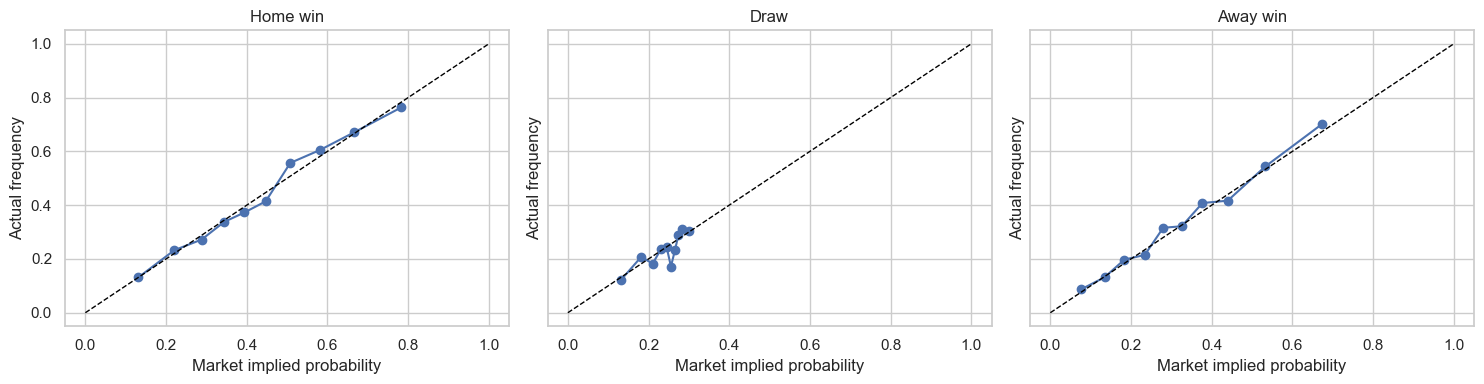

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, table, title in zip(
    axes,
    [home_calibration, draw_calibration, away_calibration],
    ['Home win', 'Draw', 'Away win'],
):
    ax.plot(table['mean_predicted_probability'], table['actual_rate'], marker='o')
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Market implied probability')
    ax.set_ylabel('Actual frequency')

plt.tight_layout()

In [9]:
ev = odds_df.copy()
ev['market_home_edge_vs_actual'] = ev['home_win'] - ev['market_prob_home']
ev['market_draw_edge_vs_actual'] = ev['draw'] - ev['market_prob_draw']
ev['market_away_edge_vs_actual'] = ev['away_win'] - ev['market_prob_away']

summary_by_prob_band = pd.concat(
    [
        calibration_table(ev, 'market_prob_home', 'home_win').assign(outcome='H'),
        calibration_table(ev, 'market_prob_draw', 'draw').assign(outcome='D'),
        calibration_table(ev, 'market_prob_away', 'away_win').assign(outcome='A'),
    ],
    ignore_index=True,
)
summary_by_prob_band

,bucket,mean_predicted_probability,actual_rate,matches,outcome
0,"(0.0407, 0.177]",0.131463,0.131579,228,H
1,"(0.177, 0.26]",0.220394,0.232456,228,H
2,"(0.26, 0.32]",0.287962,0.271930,228,H
3,"(0.32, 0.37]",0.344111,0.337719,228,H
4,"(0.37, 0.418]",0.394179,0.372807,228,H
5,"(0.418, 0.474]",0.446913,0.414097,227,H
6,"(0.474, 0.544]",0.507893,0.557018,228,H
7,"(0.544, 0.62]",0.581785,0.605263,228,H
8,"(0.62, 0.714]",0.666473,0.671053,228,H
9,"(0.714, 0.927]",0.782660,0.763158,228,H


## 6. Build Pre-Match Team Features

These features use only information available before each match. For each team, the notebook calculates rolling form, goals for, goals against, and points from previous matches.

In [ ]:

def make_team_match_rows(matches: pd.DataFrame) -> pd.DataFrame:
    home_cols = ['Date', 'season', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'home_points']
    away_cols = ['Date', 'season', 'AwayTeam', 'HomeTeam', 'FTAG', 'FTHG', 'away_points']

    optional_pairs = [
        ('home_xg', 'away_xg', 'xg'),
        ('home_shots', 'away_shots', 'shots'),
        ('home_shots_on_target', 'away_shots_on_target', 'shots_on_target'),
        ('home_corners', 'away_corners', 'corners'),
        ('home_yellow_cards', 'away_yellow_cards', 'yellow_cards'),
        ('home_red_cards', 'away_red_cards', 'red_cards'),
        ('home_fouls', 'away_fouls', 'fouls'),
        ('home_possession', 'away_possession', 'possession'),
    ]

    for home_col, away_col, _ in optional_pairs:
        if home_col in matches.columns and away_col in matches.columns:
            home_cols.append(home_col)
            away_cols.append(away_col)

    home = matches[home_cols].copy()
    away = matches[away_cols].copy()

    home_names = ['Date', 'season', 'team', 'opponent', 'goals_for', 'goals_against', 'points']
    away_names = ['Date', 'season', 'team', 'opponent', 'goals_for', 'goals_against', 'points']
    for home_col, away_col, feature_name in optional_pairs:
        if home_col in matches.columns and away_col in matches.columns:
            home_names.append(feature_name)
            away_names.append(feature_name)

    home.columns = home_names
    away.columns = away_names
    home['venue'] = 'H'
    away['venue'] = 'A'

    team_rows = pd.concat([home, away], ignore_index=True)
    team_rows = team_rows.sort_values(['team', 'Date']).reset_index(drop=True)
    return team_rows


def add_promoted_team_flags(matches: pd.DataFrame) -> pd.DataFrame:
    out = matches.copy()
    season_order = out[['season', 'Date']].groupby('season', as_index=False)['Date'].min().sort_values('Date')['season'].tolist()
    teams_by_season = {
        season: set(out.loc[out['season'].eq(season), ['HomeTeam', 'AwayTeam']].to_numpy().ravel())
        for season in season_order
    }
    promoted_by_season = {}
    for i, season in enumerate(season_order):
        promoted_by_season[season] = set() if i == 0 else teams_by_season[season] - teams_by_season[season_order[i - 1]]

    out['home_promoted_team'] = [int(team in promoted_by_season.get(season, set())) for team, season in zip(out['HomeTeam'], out['season'])]
    out['away_promoted_team'] = [int(team in promoted_by_season.get(season, set())) for team, season in zip(out['AwayTeam'], out['season'])]
    out['diff_promoted_team'] = out['home_promoted_team'] - out['away_promoted_team']
    return out


def add_rest_and_congestion_features(matches: pd.DataFrame, congestion_days: int = 14) -> pd.DataFrame:
    out = matches.sort_values('Date').copy()
    team_rows = make_team_match_rows(out)
    team_rows['rest_days'] = team_rows.groupby('team')['Date'].diff().dt.days
    team_rows[f'matches_last_{congestion_days}_days'] = (
        team_rows.groupby('team', group_keys=False)
        .apply(lambda g: g.set_index('Date')['goals_for'].rolling(f'{congestion_days}D', closed='left').count())
        .reset_index(level=0, drop=True)
        .to_numpy()
    )

    rest_cols = ['Date', 'team', 'opponent', 'rest_days', f'matches_last_{congestion_days}_days']
    home_rest = team_rows[team_rows['venue'].eq('H')][rest_cols].rename(
        columns={'team': 'HomeTeam', 'opponent': 'AwayTeam', 'rest_days': 'home_rest_days', f'matches_last_{congestion_days}_days': f'home_matches_last_{congestion_days}_days'}
    )
    away_rest = team_rows[team_rows['venue'].eq('A')][rest_cols].rename(
        columns={'team': 'AwayTeam', 'opponent': 'HomeTeam', 'rest_days': 'away_rest_days', f'matches_last_{congestion_days}_days': f'away_matches_last_{congestion_days}_days'}
    )

    out = out.merge(home_rest, on=['Date', 'HomeTeam', 'AwayTeam'], how='left')
    out = out.merge(away_rest, on=['Date', 'HomeTeam', 'AwayTeam'], how='left')
    out['diff_rest_days'] = out['home_rest_days'] - out['away_rest_days']
    out[f'diff_matches_last_{congestion_days}_days'] = out[f'home_matches_last_{congestion_days}_days'] - out[f'away_matches_last_{congestion_days}_days']
    return out


def add_elo_features(matches: pd.DataFrame, k: float = 20, home_advantage: float = 60, initial_rating: float = 1500) -> pd.DataFrame:
    out = matches.sort_values('Date').copy()
    ratings = {}
    home_pre, away_pre = [], []

    for row in out.itertuples(index=False):
        home = row.HomeTeam
        away = row.AwayTeam
        home_rating = ratings.get(home, initial_rating)
        away_rating = ratings.get(away, initial_rating)
        home_pre.append(home_rating)
        away_pre.append(away_rating)

        expected_home = 1 / (1 + 10 ** ((away_rating - (home_rating + home_advantage)) / 400))
        actual_home = 1.0 if row.FTR == 'H' else 0.5 if row.FTR == 'D' else 0.0
        change = k * (actual_home - expected_home)
        ratings[home] = home_rating + change
        ratings[away] = away_rating - change

    out['home_elo_pre'] = home_pre
    out['away_elo_pre'] = away_pre
    out['diff_elo_pre'] = out['home_elo_pre'] - out['away_elo_pre']
    return out


def add_rolling_team_features(matches: pd.DataFrame, window: int = 5) -> pd.DataFrame:
    team_rows = make_team_match_rows(matches)
    grouped = team_rows.groupby('team', group_keys=False)

    rolling_base_cols = [
        'points', 'goals_for', 'goals_against', 'xg', 'shots', 'shots_on_target',
        'corners', 'yellow_cards', 'red_cards', 'fouls', 'possession',
    ]
    rolling_cols = [col for col in rolling_base_cols if col in team_rows.columns]

    for col in rolling_cols:
        team_rows[f'rolling_{window}_{col}'] = grouped[col].transform(
            lambda s: s.shift(1).rolling(window=window, min_periods=1).mean()
        )

    team_rows[f'rolling_{window}_goal_diff'] = (
        team_rows[f'rolling_{window}_goals_for'] - team_rows[f'rolling_{window}_goals_against']
    )
    feature_cols = [f'rolling_{window}_{col}' for col in rolling_cols] + [f'rolling_{window}_goal_diff']

    home_features = team_rows[team_rows['venue'].eq('H')][['Date', 'team', 'opponent'] + feature_cols].copy()
    away_features = team_rows[team_rows['venue'].eq('A')][['Date', 'team', 'opponent'] + feature_cols].copy()

    home_features = home_features.rename(columns={'team': 'HomeTeam', 'opponent': 'AwayTeam', **{c: f'home_{c}' for c in feature_cols}})
    away_features = away_features.rename(columns={'team': 'AwayTeam', 'opponent': 'HomeTeam', **{c: f'away_{c}' for c in feature_cols}})

    out = matches.merge(home_features, on=['Date', 'HomeTeam', 'AwayTeam'], how='left')
    out = out.merge(away_features, on=['Date', 'HomeTeam', 'AwayTeam'], how='left')

    for c in feature_cols:
        out[f'diff_{c}'] = out[f'home_{c}'] - out[f'away_{c}']

    return out


def add_available_pre_match_features(matches: pd.DataFrame) -> pd.DataFrame:
    out = matches.copy()
    pre_match_pairs = [
        ('home_pre_match_xg', 'away_pre_match_xg', 'pre_match_xg'),
    ]
    for home_col, away_col, feature_name in pre_match_pairs:
        if home_col in out.columns and away_col in out.columns:
            out[f'diff_{feature_name}'] = out[home_col] - out[away_col]
    return out


model_df = odds_df.copy()
model_df['home_recent_manager_change'] = 0
model_df['away_recent_manager_change'] = 0
model_df['diff_recent_manager_change'] = 0

model_df = add_promoted_team_flags(model_df)
model_df = add_rest_and_congestion_features(model_df, congestion_days=14)
model_df = add_elo_features(model_df)
model_df = add_rolling_team_features(model_df, window=5)
model_df = add_available_pre_match_features(model_df)

model_df.head()


## 7. Feature Audit and Walk-Forward Setup


In [ ]:

required_setup_names = ['model_df', 'closing_odds_cols']
missing_setup_names = [name for name in required_setup_names if name not in globals()]
if missing_setup_names:
    raise RuntimeError(
        f"Run the notebook from the top before this section. Missing setup objects: {missing_setup_names}"
    )

season_order = model_df[['season', 'Date']].groupby('season', as_index=False)['Date'].min().sort_values('Date')['season'].tolist()
TEST_SEASON = '2025-to-2026'
if TEST_SEASON not in season_order:
    TEST_SEASON = season_order[-1]

validation_seasons = [season for season in season_order if season != TEST_SEASON]
test_mask = model_df['season'].eq(TEST_SEASON)
test_opening_sources = model_df.loc[test_mask, 'opening_odds_source'].dropna().mode()
closing_cols_present = all(col in model_df.columns for col in closing_odds_cols)
closing_benchmark_available = closing_cols_present and model_df.loc[test_mask, list(closing_odds_cols)].notna().all(axis=1).any()

feature_audit = pd.Series({
    'seasons': len(season_order),
    'matches': len(model_df),
    'test_season': TEST_SEASON,
    'test_file': 'E0 (1).csv' if model_df['source_file'].eq('E0 (1).csv').any() else 'latest available season',
    'train_seasons': ', '.join(validation_seasons),
    'test_opening_odds_source': test_opening_sources.iat[0] if len(test_opening_sources) else None,
    'closing_benchmark_available': closing_benchmark_available,
    'first_season_for_promoted_flags': season_order[0] if season_order else None,
    'manager_change_features_available': False,
})
feature_audit


## 8. Walk-Forward Validation


In [ ]:

numeric_features = [
    'market_prob_home', 'market_prob_draw', 'market_prob_away',
    'home_pre_match_xg', 'away_pre_match_xg', 'diff_pre_match_xg',
    'home_rest_days', 'away_rest_days', 'diff_rest_days',
    'home_matches_last_14_days', 'away_matches_last_14_days', 'diff_matches_last_14_days',
    'home_promoted_team', 'away_promoted_team', 'diff_promoted_team',
    'home_elo_pre', 'away_elo_pre', 'diff_elo_pre',
    'home_recent_manager_change', 'away_recent_manager_change', 'diff_recent_manager_change',
    'home_rolling_5_points', 'home_rolling_5_goals_for', 'home_rolling_5_goals_against', 'home_rolling_5_goal_diff',
    'home_rolling_5_xg', 'home_rolling_5_shots', 'home_rolling_5_shots_on_target', 'home_rolling_5_corners',
    'home_rolling_5_yellow_cards', 'home_rolling_5_red_cards', 'home_rolling_5_fouls', 'home_rolling_5_possession',
    'away_rolling_5_points', 'away_rolling_5_goals_for', 'away_rolling_5_goals_against', 'away_rolling_5_goal_diff',
    'away_rolling_5_xg', 'away_rolling_5_shots', 'away_rolling_5_shots_on_target', 'away_rolling_5_corners',
    'away_rolling_5_yellow_cards', 'away_rolling_5_red_cards', 'away_rolling_5_fouls', 'away_rolling_5_possession',
    'diff_rolling_5_points', 'diff_rolling_5_goals_for', 'diff_rolling_5_goals_against', 'diff_rolling_5_goal_diff',
    'diff_rolling_5_xg', 'diff_rolling_5_shots', 'diff_rolling_5_shots_on_target', 'diff_rolling_5_corners',
    'diff_rolling_5_yellow_cards', 'diff_rolling_5_red_cards', 'diff_rolling_5_fouls', 'diff_rolling_5_possession',
]
numeric_features = [col for col in numeric_features if col in model_df.columns]
categorical_features = ['HomeTeam', 'AwayTeam']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
    ]
)


def make_model() -> Pipeline:
    return Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]
    )


def evaluate_predictions(frame: pd.DataFrame, probabilities: pd.DataFrame) -> pd.Series:
    prob_matrix = probabilities[['model_prob_H', 'model_prob_D', 'model_prob_A']].to_numpy()
    market_matrix = frame[['market_prob_home', 'market_prob_draw', 'market_prob_away']].to_numpy()
    model_pred = np.array(['H', 'D', 'A'])[prob_matrix.argmax(axis=1)]
    market_pred = np.array(['H', 'D', 'A'])[market_matrix.argmax(axis=1)]
    actual_matrix = frame[['home_win', 'draw', 'away_win']].to_numpy()

    return pd.Series({
        'matches': len(frame),
        'model_accuracy': accuracy_score(frame['FTR'], model_pred),
        'opening_odds_accuracy': accuracy_score(frame['FTR'], market_pred),
        'model_log_loss': log_loss(frame['FTR'], prob_matrix, labels=['H', 'D', 'A']),
        'opening_odds_log_loss': log_loss(frame['FTR'], market_matrix, labels=['H', 'D', 'A']),
        'model_brier_score_multiclass': np.mean(np.sum((prob_matrix - actual_matrix) ** 2, axis=1)),
        'opening_odds_brier_score_multiclass': np.mean(np.sum((market_matrix - actual_matrix) ** 2, axis=1)),
    })


def predict_with_model(fitted_model: Pipeline, frame: pd.DataFrame) -> pd.DataFrame:
    model_classes = list(fitted_model.named_steps['classifier'].classes_)
    probs = pd.DataFrame(
        fitted_model.predict_proba(frame[numeric_features + categorical_features]),
        columns=[f'model_prob_{c}' for c in model_classes],
        index=frame.index,
    )
    for outcome in ['H', 'D', 'A']:
        if f'model_prob_{outcome}' not in probs:
            probs[f'model_prob_{outcome}'] = 0.0
    return probs[['model_prob_H', 'model_prob_D', 'model_prob_A']]


def walk_forward_by_season(data: pd.DataFrame, seasons: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    fold_metrics = []
    fold_predictions = []

    for i, season in enumerate(seasons[1:], start=1):
        train_fold = data[data['season'].isin(seasons[:i])].copy()
        test_fold = data[data['season'].eq(season)].copy()
        if train_fold.empty or test_fold.empty:
            continue

        fold_model = make_model()
        fold_model.fit(train_fold[numeric_features + categorical_features], train_fold['FTR'])
        fold_probs = predict_with_model(fold_model, test_fold)

        metrics = evaluate_predictions(test_fold, fold_probs)
        metrics['test_season'] = season
        metrics['train_matches'] = len(train_fold)
        fold_metrics.append(metrics)

        fold_predictions.append(
            test_fold[['Date', 'season', 'HomeTeam', 'AwayTeam', 'FTR', 'opening_odds_source', home_odds_col, draw_odds_col, away_odds_col]].join(fold_probs)
        )

    predictions = pd.concat(fold_predictions).sort_values('Date') if fold_predictions else pd.DataFrame()
    return pd.DataFrame(fold_metrics), predictions


walk_forward_results, walk_forward_predictions = walk_forward_by_season(model_df[model_df['season'].isin(validation_seasons)], validation_seasons)
walk_forward_results


## 9. Latest-Season Model vs Market


In [ ]:

latest_test_season = TEST_SEASON
test = model_df[model_df['season'].eq(latest_test_season)].copy()
train = model_df[model_df['Date'] < test['Date'].min()].copy()

if test.empty:
    raise ValueError(f'No rows found for test season {latest_test_season}. Check that E0 (1).csv is in the data folder and has completed results.')
if train.empty:
    raise ValueError('No historical training rows found before the test season.')

model = make_model()
X_train = train[numeric_features + categorical_features]
y_train = train['FTR']
X_test = test[numeric_features + categorical_features]
y_test = test['FTR']

model.fit(X_train, y_train)
model_probs = predict_with_model(model, test)
comparison = evaluate_predictions(test, model_probs)
comparison['test_season'] = latest_test_season
comparison['train_matches'] = len(train)
comparison['test_opening_odds_source'] = test['opening_odds_source'].dropna().mode().iat[0]
comparison


## 10. Betting Backtest and Potential Edges


In [ ]:

def add_betting_returns(edge_frame: pd.DataFrame, min_edge: float = 0.05, stake: float = 1.0, commission: float = 0.02) -> pd.DataFrame:
    out = edge_frame.copy()
    outcome_cols = {'HOME': 'H', 'DRAW': 'D', 'AWAY': 'A'}
    odds_lookup = {'HOME': home_odds_col, 'DRAW': draw_odds_col, 'AWAY': away_odds_col}
    closing_lookup = {'HOME': closing_home_odds_col, 'DRAW': closing_draw_odds_col, 'AWAY': closing_away_odds_col}

    out['bet_placed'] = out['best_model_edge'].ge(min_edge)
    out['stake'] = np.where(out['bet_placed'], stake, 0.0)
    out['bet_won'] = out['bet_placed'] & out.apply(lambda row: outcome_cols[row['best_edge_outcome']] == row['FTR'], axis=1)
    out['selected_opening_odds'] = out.apply(lambda row: row[odds_lookup[row['best_edge_outcome']]], axis=1)
    out['selected_closing_odds'] = out.apply(lambda row: row[closing_lookup[row['best_edge_outcome']]], axis=1)
    out['closing_line_value'] = out['selected_closing_odds'] / out['selected_opening_odds'] - 1
    out['profit'] = np.where(
        out['bet_won'],
        (out['selected_opening_odds'] - 1) * out['stake'] * (1 - commission),
        -out['stake'],
    )
    out.loc[~out['bet_placed'], 'profit'] = 0.0
    out['bankroll'] = out['profit'].cumsum()
    return out


edge_columns = ['Date', 'season', 'HomeTeam', 'AwayTeam', 'FTR', 'opening_odds_source', home_odds_col, draw_odds_col, away_odds_col]
if test[list(closing_odds_cols)].notna().any().any():
    edge_columns.extend(list(closing_odds_cols))

edge_df = test[edge_columns].copy()
for col in closing_odds_cols:
    if col not in edge_df:
        edge_df[col] = np.nan
edge_df = edge_df.join(model_probs[['model_prob_H', 'model_prob_D', 'model_prob_A']])

edge_df['ev_home'] = edge_df['model_prob_H'] * edge_df[home_odds_col] - 1
edge_df['ev_draw'] = edge_df['model_prob_D'] * edge_df[draw_odds_col] - 1
edge_df['ev_away'] = edge_df['model_prob_A'] * edge_df[away_odds_col] - 1

edge_df['best_model_edge'] = edge_df[['ev_home', 'ev_draw', 'ev_away']].max(axis=1)
edge_df['best_edge_outcome'] = edge_df[['ev_home', 'ev_draw', 'ev_away']].idxmax(axis=1).str.replace('ev_', '').str.upper()

backtest_df = add_betting_returns(edge_df, min_edge=0.05, stake=1.0, commission=0.02)
backtest_summary = pd.Series({
    'test_season': latest_test_season,
    'odds_used': test['opening_odds_source'].dropna().mode().iat[0],
    'edge_threshold': 0.05,
    'commission': 0.02,
    'bets': int(backtest_df['bet_placed'].sum()),
    'staked': backtest_df['stake'].sum(),
    'profit': backtest_df['profit'].sum(),
    'roi_on_staked': backtest_df['profit'].sum() / backtest_df['stake'].sum() if backtest_df['stake'].sum() else np.nan,
    'hit_rate': backtest_df.loc[backtest_df['bet_placed'], 'bet_won'].mean() if backtest_df['bet_placed'].any() else np.nan,
    'avg_closing_line_value_on_bets': backtest_df.loc[backtest_df['bet_placed'], 'closing_line_value'].mean(),
})

backtest_summary


## Implemented Improvements

- The notebook now trains on historical seasons before the 2025-2026 test set and uses `E0 (1).csv` as the explicit 2025-2026 test file when present.
- The 2025-2026 benchmark uses Bet365 opening odds: `B365H`, `B365D`, and `B365A`.
- Bet365 closing odds, `B365CH`, `B365CD`, and `B365CA`, are retained for closing-line-value comparison but are not used as the betting benchmark.
- Historical PremCSV seasons still use their available 1X2 odds so the model can learn market-implied probabilities across prior seasons.
- Added no-lookahead features for rest days, fixture congestion, inferred promoted teams, Elo ratings, pre-match xG, and rolling xG/shots/cards/corners/fouls/possession.
- Added a betting backtest with configurable edge threshold, flat stake, commission, and average closing-line value on placed bets.


## 11. Portfolio Model Comparison

This section compares the opening market against several deliberately simple alternatives. The goal is not to find a lucky profitable slice, but to test whether extra information consistently improves probability quality over the bookmaker benchmark.


In [ ]:

def model_probability_frame(frame: pd.DataFrame, prefix: str = 'model_prob') -> pd.DataFrame:
    return frame[[f'{prefix}_H', f'{prefix}_D', f'{prefix}_A']].rename(
        columns={f'{prefix}_H': 'prob_H', f'{prefix}_D': 'prob_D', f'{prefix}_A': 'prob_A'}
    )


def market_probability_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            'prob_H': frame['market_prob_home'],
            'prob_D': frame['market_prob_draw'],
            'prob_A': frame['market_prob_away'],
        },
        index=frame.index,
    )


def probability_metrics(frame: pd.DataFrame, probs: pd.DataFrame, label: str) -> pd.Series:
    prob_matrix = probs[['prob_H', 'prob_D', 'prob_A']].to_numpy()
    actual_matrix = frame[['home_win', 'draw', 'away_win']].to_numpy()
    pred = np.array(['H', 'D', 'A'])[prob_matrix.argmax(axis=1)]
    return pd.Series(
        {
            'model': label,
            'matches': len(frame),
            'accuracy': accuracy_score(frame['FTR'], pred),
            'log_loss': log_loss(frame['FTR'], prob_matrix, labels=['H', 'D', 'A']),
            'brier_score_multiclass': np.mean(np.sum((prob_matrix - actual_matrix) ** 2, axis=1)),
        }
    )


def make_feature_model(feature_cols: list[str], cat_cols: list[str] | None = None, c: float = 1.0) -> Pipeline:
    cat_cols = cat_cols or []
    return Pipeline(
        steps=[
            (
                'preprocess',
                ColumnTransformer(
                    transformers=[
                        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), feature_cols),
                        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
                    ],
                    remainder='drop',
                ),
            ),
            ('classifier', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, C=c)),
        ]
    )


def predict_feature_model(fitted_model: Pipeline, frame: pd.DataFrame, feature_cols: list[str], cat_cols: list[str] | None = None) -> pd.DataFrame:
    cat_cols = cat_cols or []
    classes = list(fitted_model.named_steps['classifier'].classes_)
    raw = pd.DataFrame(
        fitted_model.predict_proba(frame[feature_cols + cat_cols]),
        columns=[f'prob_{klass}' for klass in classes],
        index=frame.index,
    )
    for outcome in ['H', 'D', 'A']:
        if f'prob_{outcome}' not in raw:
            raw[f'prob_{outcome}'] = 0.0
    return raw[['prob_H', 'prob_D', 'prob_A']]


market_features = ['market_prob_home', 'market_prob_draw', 'market_prob_away']
team_numeric_features = [col for col in numeric_features if col not in market_features]
elo_features = [col for col in ['home_elo_pre', 'away_elo_pre', 'diff_elo_pre'] if col in numeric_features]

model_specs = {
    'Market only': {'kind': 'market'},
    'Team features only': {'features': team_numeric_features, 'categoricals': categorical_features},
    'Elo only': {'features': elo_features, 'categoricals': []},
    'Market + team features': {'features': numeric_features, 'categoricals': categorical_features},
    'Regularized market + team': {'features': numeric_features, 'categoricals': categorical_features, 'c': 0.2},
}

variant_probabilities = {}
model_comparison_rows = []

for label, spec in model_specs.items():
    if spec.get('kind') == 'market':
        probs = market_probability_frame(test)
    else:
        feature_cols = spec['features']
        cat_cols = spec.get('categoricals', [])
        fitted = make_feature_model(feature_cols, cat_cols, c=spec.get('c', 1.0))
        fitted.fit(train[feature_cols + cat_cols], train['FTR'])
        probs = predict_feature_model(fitted, test, feature_cols, cat_cols)

    variant_probabilities[label] = probs
    model_comparison_rows.append(probability_metrics(test, probs, label))

# Tune a market/model blend on the last historical validation season, then apply it once to 2025-2026.
blend_validation_season = validation_seasons[-1]
blend_train = model_df[model_df['season'].isin(validation_seasons[:-1])].copy()
blend_validation = model_df[model_df['season'].eq(blend_validation_season)].copy()
blend_model = make_feature_model(numeric_features, categorical_features, c=0.2)
blend_model.fit(blend_train[numeric_features + categorical_features], blend_train['FTR'])
validation_model_probs = predict_feature_model(blend_model, blend_validation, numeric_features, categorical_features)
validation_market_probs = market_probability_frame(blend_validation)

alpha_grid = np.linspace(0, 1, 21)
blend_scores = []
for alpha in alpha_grid:
    blended_validation = (1 - alpha) * validation_market_probs + alpha * validation_model_probs
    blend_scores.append(
        {
            'alpha_model_weight': alpha,
            'validation_log_loss': log_loss(blend_validation['FTR'], blended_validation[['prob_H', 'prob_D', 'prob_A']], labels=['H', 'D', 'A']),
        }
    )
blend_tuning = pd.DataFrame(blend_scores)
best_alpha = blend_tuning.sort_values('validation_log_loss').iloc[0]['alpha_model_weight']

final_blend_model = make_feature_model(numeric_features, categorical_features, c=0.2)
final_blend_model.fit(train[numeric_features + categorical_features], train['FTR'])
final_model_probs = predict_feature_model(final_blend_model, test, numeric_features, categorical_features)
market_test_probs = market_probability_frame(test)
blended_test_probs = (1 - best_alpha) * market_test_probs + best_alpha * final_model_probs

variant_probabilities['Tuned market/model blend'] = blended_test_probs
model_comparison_rows.append(probability_metrics(test, blended_test_probs, 'Tuned market/model blend'))

model_comparison = pd.DataFrame(model_comparison_rows).sort_values('log_loss').reset_index(drop=True)
model_comparison['log_loss_vs_market'] = model_comparison['log_loss'] - model_comparison.loc[model_comparison['model'].eq('Market only'), 'log_loss'].iat[0]
model_comparison['brier_vs_market'] = model_comparison['brier_score_multiclass'] - model_comparison.loc[model_comparison['model'].eq('Market only'), 'brier_score_multiclass'].iat[0]
model_comparison


## 12. Betting, CLV, and Segment Diagnostics

A model can look interesting on accuracy and still be useless for betting. These diagnostics test expected-value bets, realised ROI, closing-line value, and where model disagreement with the market is concentrated.


In [ ]:

def edge_backtest_for_probs(frame: pd.DataFrame, probs: pd.DataFrame, label: str, min_edge: float = 0.05, stake: float = 1.0, commission: float = 0.02) -> tuple[pd.Series, pd.DataFrame]:
    out = frame[['Date', 'season', 'HomeTeam', 'AwayTeam', 'FTR', home_odds_col, draw_odds_col, away_odds_col, closing_home_odds_col, closing_draw_odds_col, closing_away_odds_col]].copy()
    out = out.join(probs.add_prefix('model_'))

    out['ev_home'] = out['model_prob_H'] * out[home_odds_col] - 1
    out['ev_draw'] = out['model_prob_D'] * out[draw_odds_col] - 1
    out['ev_away'] = out['model_prob_A'] * out[away_odds_col] - 1
    out['best_model_edge'] = out[['ev_home', 'ev_draw', 'ev_away']].max(axis=1)
    out['best_edge_outcome'] = out[['ev_home', 'ev_draw', 'ev_away']].idxmax(axis=1).str.replace('ev_', '').str.upper()

    out = add_betting_returns(out, min_edge=min_edge, stake=stake, commission=commission)
    placed = out['bet_placed']
    summary = pd.Series(
        {
            'model': label,
            'bets': int(placed.sum()),
            'staked': out['stake'].sum(),
            'profit': out['profit'].sum(),
            'roi_on_staked': out['profit'].sum() / out['stake'].sum() if out['stake'].sum() else np.nan,
            'hit_rate': out.loc[placed, 'bet_won'].mean() if placed.any() else np.nan,
            'avg_edge_on_bets': out.loc[placed, 'best_model_edge'].mean() if placed.any() else np.nan,
            'avg_clv_on_bets': out.loc[placed, 'closing_line_value'].mean() if placed.any() else np.nan,
            'positive_clv_rate': out.loc[placed, 'closing_line_value'].gt(0).mean() if placed.any() else np.nan,
        }
    )
    return summary, out


backtest_summaries = []
variant_backtests = {}
for label, probs in variant_probabilities.items():
    summary, details = edge_backtest_for_probs(test, probs, label, min_edge=0.05, stake=1.0, commission=0.02)
    backtest_summaries.append(summary)
    variant_backtests[label] = details

portfolio_backtest_summary = pd.DataFrame(backtest_summaries).sort_values('roi_on_staked', ascending=False).reset_index(drop=True)

best_log_loss_model = model_comparison.iloc[0]['model']
best_backtest_model = portfolio_backtest_summary.iloc[0]['model']
selected_model_for_diagnostics = best_log_loss_model
selected_probs = variant_probabilities[selected_model_for_diagnostics]
selected_backtest = variant_backtests[selected_model_for_diagnostics]

portfolio_backtest_summary


## 13. Portfolio Visuals

These charts are designed for the project write-up: probability quality, calibration, profit curve, closing-line value, and market disagreement.


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=model_comparison, x='log_loss', y='model', ax=axes[0, 0], color='#4C78A8')
axes[0, 0].axvline(model_comparison.loc[model_comparison['model'].eq('Market only'), 'log_loss'].iat[0], color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Probability quality vs opening market')
axes[0, 0].set_xlabel('Log loss, lower is better')
axes[0, 0].set_ylabel('')

fixed_bins = np.linspace(0, 1, 11)
calibration_plot = []
for label, probs in {'Opening market': market_probability_frame(test), selected_model_for_diagnostics: selected_probs}.items():
    tmp = test[['home_win', 'draw', 'away_win']].copy()
    tmp = tmp.join(probs)
    for outcome, actual_col in [('H', 'home_win'), ('D', 'draw'), ('A', 'away_win')]:
        bucketed = tmp[[f'prob_{outcome}', actual_col]].dropna().copy()
        bucketed['bucket'] = pd.cut(bucketed[f'prob_{outcome}'], bins=fixed_bins, include_lowest=True)
        grouped = bucketed.groupby('bucket', observed=True).agg(
            mean_probability=(f'prob_{outcome}', 'mean'),
            actual_rate=(actual_col, 'mean'),
            matches=(actual_col, 'size'),
        ).reset_index()
        grouped['source'] = label
        grouped['outcome'] = outcome
        calibration_plot.append(grouped)
calibration_plot = pd.concat(calibration_plot, ignore_index=True)

sns.scatterplot(data=calibration_plot, x='mean_probability', y='actual_rate', hue='source', style='outcome', size='matches', sizes=(30, 160), ax=axes[0, 1])
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[0, 1].set_title('Fixed-bucket calibration')
axes[0, 1].set_xlabel('Predicted probability')
axes[0, 1].set_ylabel('Actual frequency')
axes[0, 1].legend(loc='best', fontsize=8)

placed = selected_backtest[selected_backtest['bet_placed']].copy()
if not placed.empty:
    axes[1, 0].plot(placed['Date'], placed['profit'].cumsum(), color='#F58518')
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_title(f'Profit curve: {selected_model_for_diagnostics}')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Units')

if not placed.empty:
    sns.histplot(placed['closing_line_value'].dropna(), bins=25, ax=axes[1, 1], color='#54A24B')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('Closing-line value on placed bets')
axes[1, 1].set_xlabel('Closing odds / opening odds - 1')
axes[1, 1].set_ylabel('Bets')

plt.tight_layout()


## 14. Market Disagreement and Segments

This section looks at when the model most disagrees with the opening market. If a project claims market inefficiency, this is where the evidence should appear.


In [ ]:

diagnostic_df = test[['Date', 'season', 'HomeTeam', 'AwayTeam', 'FTR', home_odds_col, draw_odds_col, away_odds_col]].copy()
diagnostic_df = diagnostic_df.join(market_probability_frame(test).add_prefix('market_'))
diagnostic_df = diagnostic_df.join(selected_probs.add_prefix('selected_'))

diagnostic_df['market_pick'] = np.array(['H', 'D', 'A'])[diagnostic_df[['market_prob_H', 'market_prob_D', 'market_prob_A']].to_numpy().argmax(axis=1)]
diagnostic_df['model_pick'] = np.array(['H', 'D', 'A'])[diagnostic_df[['selected_prob_H', 'selected_prob_D', 'selected_prob_A']].to_numpy().argmax(axis=1)]
diagnostic_df['model_market_disagreement'] = diagnostic_df['model_pick'].ne(diagnostic_df['market_pick'])
diagnostic_df['max_probability_shift'] = np.abs(
    diagnostic_df[['selected_prob_H', 'selected_prob_D', 'selected_prob_A']].to_numpy()
    - diagnostic_df[['market_prob_H', 'market_prob_D', 'market_prob_A']].to_numpy()
).max(axis=1)
diagnostic_df['market_favourite_odds'] = diagnostic_df[[home_odds_col, draw_odds_col, away_odds_col]].min(axis=1)
diagnostic_df['odds_band'] = pd.cut(
    diagnostic_df['market_favourite_odds'],
    bins=[1.0, 1.5, 2.0, 3.0, 5.0, np.inf],
    labels=['heavy favourite', 'clear favourite', 'competitive', 'outsider-led', 'longshot-led'],
)

segment_summary = (
    diagnostic_df.groupby('odds_band', observed=True)
    .agg(
        matches=('FTR', 'size'),
        model_market_disagreement_rate=('model_market_disagreement', 'mean'),
        avg_max_probability_shift=('max_probability_shift', 'mean'),
        market_pick_accuracy=('market_pick', lambda s: (s == diagnostic_df.loc[s.index, 'FTR']).mean()),
        model_pick_accuracy=('model_pick', lambda s: (s == diagnostic_df.loc[s.index, 'FTR']).mean()),
    )
    .reset_index()
)

largest_disagreements = diagnostic_df.sort_values('max_probability_shift', ascending=False).head(20)[
    ['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'market_pick', 'model_pick', 'max_probability_shift', home_odds_col, draw_odds_col, away_odds_col]
]

segment_summary


In [ ]:

largest_disagreements


## 15. Portfolio Conclusion

The strongest conclusion is methodological: Premier League opening odds are hard to beat, and extra football features did not automatically create a profitable betting edge. That is still a useful market-efficiency result.


In [ ]:

market_row = model_comparison[model_comparison['model'].eq('Market only')].iloc[0]
best_probability_row = model_comparison.iloc[0]
best_backtest_row = portfolio_backtest_summary.iloc[0]

portfolio_conclusion = pd.Series(
    {
        'test_season': latest_test_season,
        'test_matches': len(test),
        'opening_market_log_loss': market_row['log_loss'],
        'best_model_by_log_loss': best_probability_row['model'],
        'best_model_log_loss': best_probability_row['log_loss'],
        'best_model_log_loss_vs_market': best_probability_row['log_loss_vs_market'],
        'best_backtest_model': best_backtest_row['model'],
        'best_backtest_roi': best_backtest_row['roi_on_staked'],
        'best_backtest_avg_clv': best_backtest_row['avg_clv_on_bets'],
        'interpretation': 'No robust evidence of a profitable edge unless a model beats the opening market and shows positive closing-line value.',
    }
)
portfolio_conclusion
